This Jupyter notebook contains the Python script used to implement the Random Forest Regression modelpresented in this study, including model training, performance evaluation, feature importance, and interpretability analysis 

# 1. Import necessary packages/libraries

In [3]:

import os
import pandas as pd
import numpy as np

#Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import matplotlib.dates as mdates
from matplotlib.ticker import FixedLocator, AutoMinorLocator, MultipleLocator, ScalarFormatter

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV, train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay, partial_dependence
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#SHapley Additive exPlnations
%pip install shap
import shap
# Import Fabio Crameri colormaps
%pip install cmcrameri
import cmcrameri.cm as cmc



   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 9.8 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


# 2. Load groundwater data file

In [39]:
#Load processed field porewater data
df = pd.read_csv('full_groundwater_dataset.csv')
print('File loaded')
print("Columns in the dataset:",df.columns)
print("No. of North samples:", len(df[df['Site'] == 'Upham North']))
print("No. of West samples:", len(df[df['Site'] == 'Upham West']))

File loaded
Columns in the dataset: Index(['Date', 'Total P (mg/L)', 'Alkalinity as CaCO3 (mg/L)', 'pH',
       'DO (mg/L)', 'EC (uS/cm)', 'Distance from datum (m)',
       'Orthophosphate (mg/L)', 'Site', 'NO3 (mg/L)', 'SO4 (mg/L)',
       'Avg hyporheic gradient', 'Depth below water table (cm)',
       'WD_Elev (ft)', 'WD_Discharge (cfs)', 'CR_Elev (ft)'],
      dtype='object')
No. of North samples: 170
No. of West samples: 259


In [40]:
# Identify dependent variables (features) to use in subsequent analysis and random forest model
features = ['pH','DO (mg/L)', 'EC (uS/cm)','Distance from datum (m)',
        'NO3 (mg/L)','SO4 (mg/L)','Avg hyporheic gradient','Depth below water table (cm)']
X_all= df[features] #exclude Ortho-P and site
X_all_w_site = df[features+['Site']]

#Independent variable
y = df['Orthophosphate (mg/L)']  

# 3. Compute correlation matrix among features

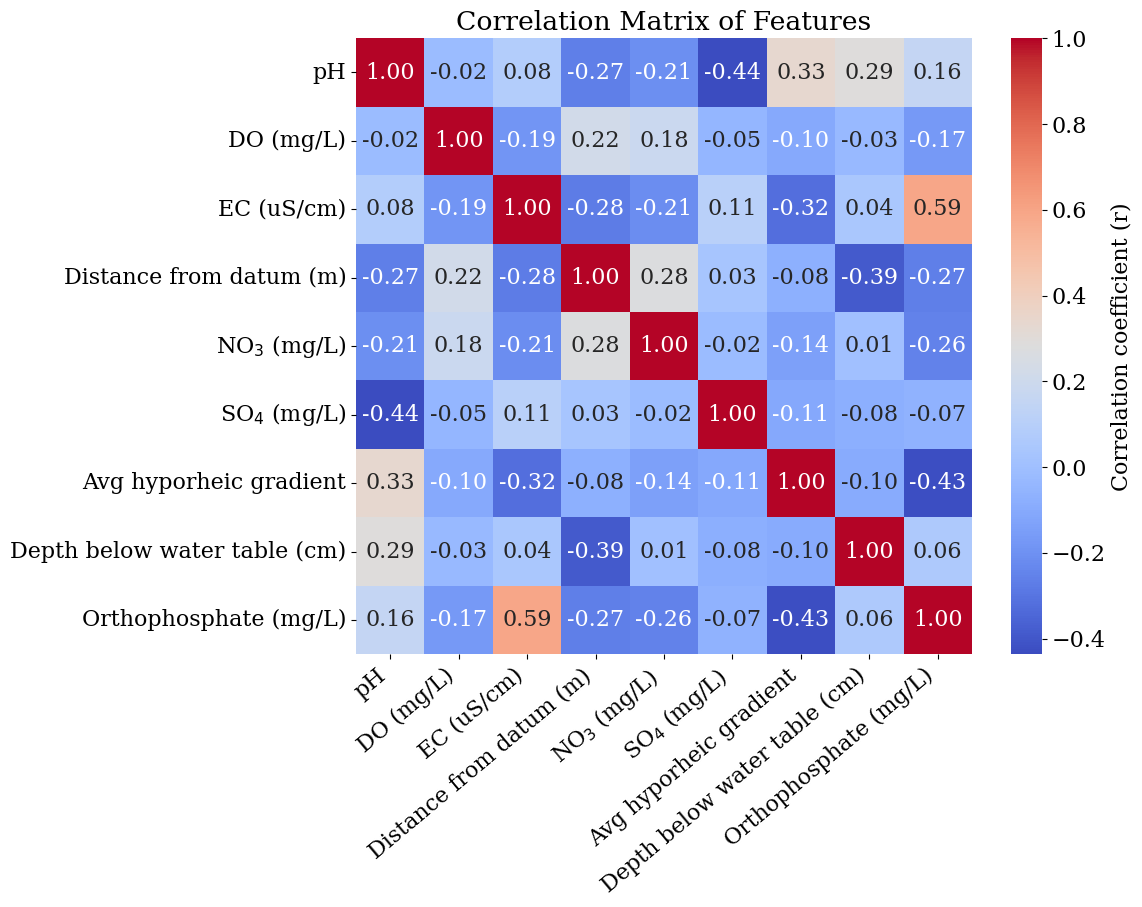

In [41]:
# Compute correlation matrix (all feature+orthoP)
X_all_w_P = df[features+['Orthophosphate (mg/L)']]
rename_map = {"NO3 (mg/L)": r"NO$_3$ (mg/L)", "SO4 (mg/L)": r"SO$_4$ (mg/L)"}
corr_matrix = X_all_w_P.corr()
corr_matrix = corr_matrix.rename(index=rename_map, columns=rename_map)

# Display correlation matrix as a heatmap
plt.rcParams.update({'font.size': 16,'font.family': 'DejaVu Serif'})  # 'DejaVu Sans'
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True,   
            cbar_kws={'label': 'Correlation coefficient (r)'})
plt.title("Correlation Matrix of Features")
plt.xticks(rotation=40, ha='right')
plt.show()

# 4. Main Model: Random Forest regressor with 5-fold cross-validation
Model workflow:

1. Cross-validation set up: in each fold, the data is split into 80% training and 20% out-of-fold (OOF) test sets with random shuffling before splitting
2. Model training per fold & make predictions on both training and OOF test set
3. Performance metrics: Compute average $R^2$ scores for training, OOF test, and out-of-bag (OOB) sets and root mean square error (RMSE) on the OOF test set.
5. Collect Gini feature importance and compute permutation importance on OOF test set in each fold
6. Calculate SHAP values on each OOF test set and combine all values from 5 folds
7. Computes PDPs for each feature within each fold using the training data.

In [42]:
# --- Parameter setup ---
# Get site labels
site_labels = df["Site"].values

# --- 4.1 Cross-validation set up ---
n_splits=5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
# --- Initialize empty lists to store results ---
fold_importances = [] #for Gini Importance
fold_perm_importances =[] #for Permutation Importance
rmse_list = []  # Unit same as orthoP = mg/L
r2_train_scores = [] #for training R2 scores
r2_test_scores = [] #for out-of-fold R2 scores
r2_oob_scores = []   #for out-of-bag R2 scores
shap_values_all = [] #for SHAP values
feature_values_all = []
X_all_fold= []
y_test_all = []
y_pred_all = []
site_all = []
pdp_all = {feat: [] for feat in features}

In [43]:
### --- 4a) MAIN MODEL---
# --- Cross-validation loop ---
for fold, (train_idx, test_idx) in enumerate(kf.split(X_all)):
    X_train, X_test = X_all.iloc[train_idx], X_all.iloc[test_idx]  # Site info excluded when training model
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    site_test = site_labels[test_idx]

    # 4.2. Train Random Forest
    # Model Hyperparamters
    model_params = {
    'n_estimators': 300,
    'max_depth': 10,
    'min_samples_leaf': 3,
    'max_features': 'sqrt',
    'random_state': 42,
    'oob_score': True,
    'n_jobs': -1}

    model = RandomForestRegressor(**model_params)
    model.fit(X_train, y_train)

    # --- 4.2 and 4.3. Predictions & metrics ---
    # a) Predict and store test R2
    y_pred_test = model.predict(X_test)
    r2_test = r2_score(y_test, y_pred_test)
    r2_test_scores.append(r2_test)

    # b) Predict and store Training R²
    y_pred_train = model.predict(X_train)
    r2_train = r2_score(y_train, y_pred_train)
    r2_train_scores.append(r2_train)

    # c) OOB R²
    r2_oob = model.oob_score_
    r2_oob_scores.append(r2_oob)

    # d) RMSE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    rmse_list.append(rmse)

    # --- 4.4. Save Feature importance ---
    # Gini feature importance
    fold_importances.append(model.feature_importances_) 
    # Permutation importance on OOF test set in each fold
    perm = permutation_importance(model, X_test, y_test, n_repeats=20, random_state=42, n_jobs=-1)
    fold_perm_importances.append(perm.importances_mean)

    # --- 4.5. SHAP values (compute on test)---
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    shap_values_all.append(shap_values)
    X_all_fold.append(X_test)
    
    # --- 4.6. Compute PDP for each feature ---
    for feat in features:
      pdp_result = partial_dependence(model, X_train, features=[feat],
            grid_resolution=100,kind='average' )
      # Extract grid and average values
      if 'values' in pdp_result:
        values = pdp_result['values'][0]
      else:
        values = pdp_result['grid_values'][0]
      avg_pred = pdp_result['average'][0]
        # Save this fold’s PDP
      pdp_all[feat].append({ "fold": fold, "x": values, "y": avg_pred})

    # ---- Store predictions on OOF test set in numpy arrays ---
    y_test_all.append(y_test.values)  
    y_pred_all.append(y_pred_test)    
    site_all.append(site_test) 



## Computes CV-averaged feature importance, permutation importance, and SHAP values from each fold


In [44]:
# --- Combine SHAP values ---
shap_values_combined = np.concatenate(shap_values_all, axis=0)

# --- Combine all ortho-P predictions made in each fold vs actual values---
X_combined = pd.concat(X_all_fold, axis=0)
y_test_all = np.concatenate(y_test_all) # =y_combined
y_pred_all = np.concatenate(y_pred_all)
site_all   = np.concatenate(site_all)

# --- Calculate CV-averaged feature importance scores ---
cv_importances = pd.Series(np.mean(fold_importances, axis=0), index=X_all.columns, name="Gini Feature importance")
cv_perm_importances = pd.Series(np.mean(fold_perm_importances, axis=0), index=X_all.columns, name="Permutation importance")
importances_compare = pd.concat([cv_importances, cv_perm_importances], axis=1).sort_values("Permutation importance", ascending=True)
print("\nCV-averaged Feature Importances:")
print(importances_compare)



CV-averaged Feature Importances:
                              Gini Feature importance  Permutation importance
DO (mg/L)                                    0.093981                0.016684
SO4 (mg/L)                                   0.056639                0.019804
Depth below water table (cm)                 0.055344                0.034277
Distance from datum (m)                      0.090062                0.072540
pH                                           0.104971                0.091582
NO3 (mg/L)                                   0.141581                0.127642
EC (uS/cm)                                   0.301694                0.160418
Avg hyporheic gradient                       0.155728                0.230758


4c) Computes OOB predictions
d) Computes root mean square error (RMSE) per site and plots predicted vs measured P (color coded by site)
d) In each fold, rain final model on all data (100%, no held out test set) for partial dependence plot

# 5. Model performance evaluation based on $R^2$, RMSE, and site-specific analysis

In [45]:
# --- Calculate CV-averaged R2 scores (train, OOF test, OOB sets)---
r2_train_mean = np.mean(r2_train_scores)  # training R2
r2_test_mean = np.mean(r2_test_scores)    # test R2
r2_oob_mean = np.mean(r2_oob_scores)      # OOB R2

print(f"\n--- Model performance summary ({n_splits}-fold CV) ---")
print(f"R² Test: {r2_test_mean:.3f} ± {np.std(r2_test_scores):.3f}")
print(f"R² Train: {r2_train_mean:.3f}± {np.std(r2_train_scores):.3f}")
print(f"OOB R²:  {r2_oob_mean:.3f}± {np.std(r2_oob_scores):.3f}")
print(f"RMSE: {np.mean(rmse_list):.3f} ± {np.std(rmse_list):.3f}")



--- Model performance summary (5-fold CV) ---
R² Test: 0.658 ± 0.120
R² Train: 0.855± 0.010
OOB R²:  0.663± 0.027
RMSE: 0.052 ± 0.010


In [46]:
# Define a function to evaluate site-specific performance
def compute_site_metrics(y_test_all, y_pred_all, site_all):
    """
    Compute per-site R², RMSE, and standard deviation of errors.

    Parameters
    ----------
    y_true_all : np.ndarray
        True target values for all samples.
    y_pred_all : np.ndarray
        Predicted target values for all samples.
    site_all : np.ndarray or list
        Site labels corresponding to each sample.

    Returns
    -------
    site_metrics : dict
        Dictionary with site names as keys. Each value is another dict with keys:
        - 'R2': R²
        - 'RMSE': Root Mean Squared Error
        - 'StdDev': standard deviation of prediction errors
    """
    site_metrics = {}
    for site in np.unique(site_all):
        mask = site_all == site
        y_test_site = y_test_all[mask]
        y_pred_site = y_pred_all[mask]

        r2_site = r2_score(y_test_site, y_pred_site)
        rmse_site = np.sqrt(mean_squared_error(y_test_site, y_pred_site))
        r2_std_site = np.std(y_pred_site - y_test_site)

        site_metrics[site] = {"R2": r2_site, "R2 stdv": r2_std_site,"RMSE": rmse_site,}

        print(f"--- CV-average test R² for {site} ---")
        print(f"R² = {r2_site:.3f} ± {r2_std_site:.3f}, RMSE = {rmse_site:.3f} mg/L\n")

    return site_metrics

# Evalute site performance
site_metrics = compute_site_metrics(y_test_all, y_pred_all, site_all)

--- CV-average test R² for Upham North ---
R² = 0.634 ± 0.073, RMSE = 0.073 mg/L

--- CV-average test R² for Upham West ---
R² = 0.298 ± 0.033, RMSE = 0.033 mg/L



## Plot site-specific model performance (Figure S1)

RMSE_North: 0.0734 mg/L, 16.22 % of the orthophosphate range at North
RMSE_West: 0.0335 mg/L, 7.39 % of the orthophosphate range at West


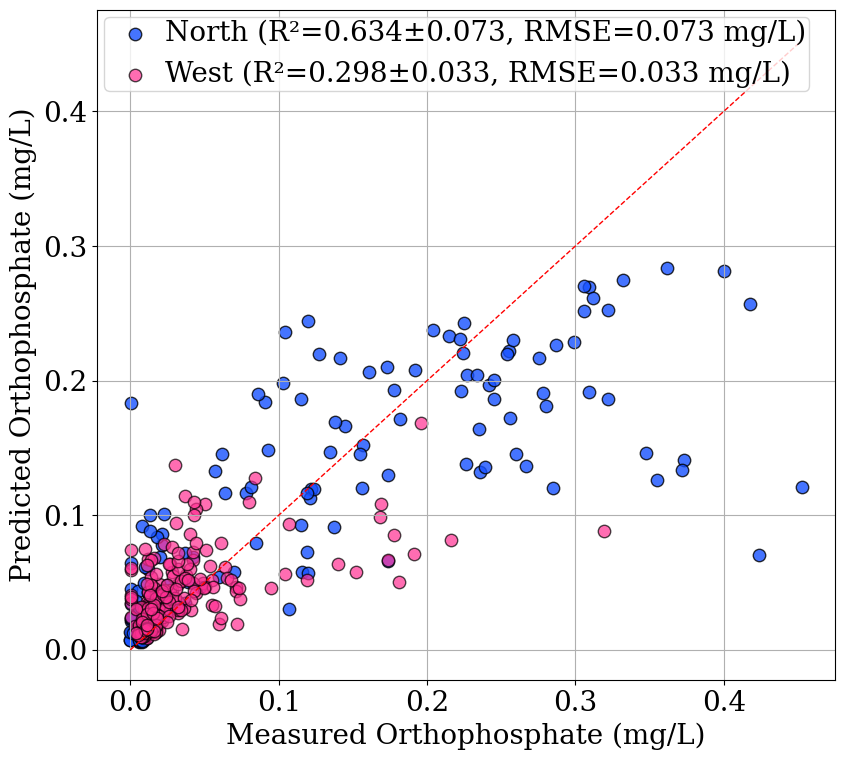

In [47]:

#--- Predicted vs Measured Orthophosphate per site ---
# ensure arrays
y_test_all = np.array(y_test_all)
y_pred_all = np.array(y_pred_all)
site_all = np.array(site_all)

mask_north = site_all == "Upham North"
mask_west  = site_all == "Upham West"

rmse_north = np.sqrt(mean_squared_error(y_test_all[mask_north], y_pred_all[mask_north]))
rmse_west  = np.sqrt(mean_squared_error(y_test_all[mask_west], y_pred_all[mask_west]))

ortho_north = df.loc[df['Site'] == 'Upham North', 'Orthophosphate (mg/L)']
ortho_west= df.loc[df['Site'] == 'Upham North', 'Orthophosphate (mg/L)']
rmse_north_pct = rmse_north / (ortho_north.max() - ortho_north.min()) * 100
rmse_west_pct = rmse_west / (ortho_west.max() - ortho_west.min())*100
print("RMSE_North:", round(rmse_north, 4), "mg/L,", round(rmse_north_pct, 2), "% of the orthophosphate range at North")
print("RMSE_West:", round(rmse_west, 4), "mg/L,", round(rmse_west_pct, 2), "% of the orthophosphate range at West")


plt.figure(figsize=(9,8))  # for paper 10,6, for presentation 6.5,6
plt.rcParams.update({'font.size': 20, 'font.family': 'DejaVu Serif'}) 
bright_blue = "#1751FF"  #color choices
bright_pink = "#ff2f92"
plt.scatter(y_test_all[mask_north], y_pred_all[mask_north],
            color=bright_blue, alpha=0.8, s=80, edgecolor='k',
            label=(f'North (R²={site_metrics["Upham North"]["R2"]:.3f}±'
                   f'{site_metrics["Upham North"]["R2 stdv"]:.3f}, '
                   f'RMSE={site_metrics["Upham North"]["RMSE"]:.3f} mg/L)'))
plt.scatter(y_test_all[mask_west], y_pred_all[mask_west],
            color=bright_pink, alpha=0.7, s=80, edgecolor='k',
            label=(f'West (R²={site_metrics["Upham West"]["R2"]:.3f}±'
                   f'{site_metrics["Upham West"]["R2 stdv"]:.3f}, '
                   f'RMSE={site_metrics["Upham West"]["RMSE"]:.3f} mg/L)'))

min_val = min(y_test_all.min(), y_pred_all.min())
max_val = max(y_test_all.max(), y_pred_all.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1)

plt.xlabel("Measured Orthophosphate (mg/L)")
plt.ylabel("Predicted Orthophosphate (mg/L)")
#plt.title("Predicted vs Measured Orthophosphate (Colored by Site)")
plt.legend(
    handletextpad=0.1,        # closer text to marker
    loc='upper left',          # choose a corner inside the axes
    bbox_to_anchor=(0.0099, 0.99),  # fine-tune position (x, y) in axes fraction
    borderaxespad=0,   # padding between legend and axes
    borderpad=0.1,
    frameon=True)               # show legend box
plt.grid(True)
plt.tight_layout()
plt.show()

# 6. Generate SHAP summary plot (Figure 3B)
The SHAP values from all 5 cross-validations fold are aggregated. 


Generating main SHAP plot for 8 environmental features.


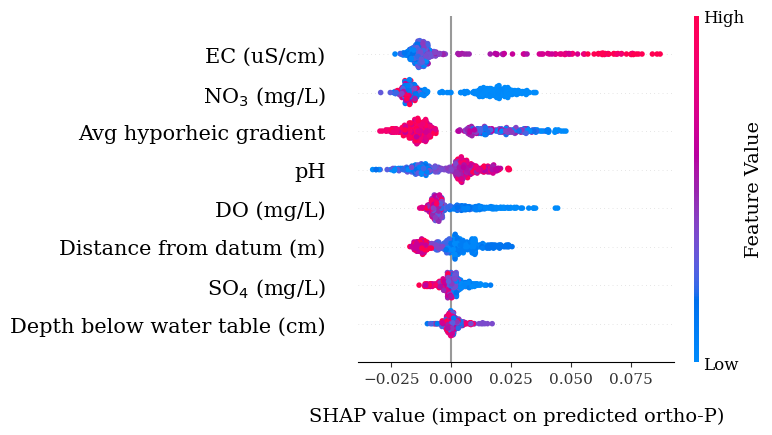

In [48]:
plt.rcParams.update({'font.size': 18,'font.family': 'DejaVu Serif'})  # 'DejaVu Sans'


# Identify non-site features
all_feature_cols = X_combined.columns.tolist()
non_site_indices_shap =[all_feature_cols.index(col) for col in features if col in all_feature_cols]

# --- Format feature names for plotting (chemical subscripts) ---
formatted_features = [rename_map.get(f, f) for f in features]

# Slice SHAP values to include only non-site features
shap_values_summary = shap_values_combined[:, non_site_indices_shap]
X_summary = X_combined[features]
print(f"\nGenerating main SHAP plot for {len(features)} environmental features.")

#--- Main SHAP summary plot ---
if isinstance(shap_values_summary, list):
    # sometimes TreeExplainer returns a list for multi-output
    shap.summary_plot(shap_values_summary[0], X_summary, feature_names=formatted_features, show=False)
else:
    shap.summary_plot(shap_values_summary, X_summary, feature_names=formatted_features, show=False)

# --- Axis formatting  ---
plt.xlabel("SHAP value (impact on predicted ortho-P)", fontsize=14, labelpad=15) #
plt.yticks(fontsize=15, color='black')  # optional: make y-axis consistent too

# --- Color bar adjustments ---
cbar_ax = plt.gcf().axes[-1]  # last axis is colorbar
cbar_ax.tick_params(labelsize=12)         # tick labels font size
cbar_ax.set_ylabel("Feature Value", fontsize=14, labelpad=0)  # label font
plt.tight_layout()
plt.show()

# 7. Generate Feature Importance plot (Figure 3A)
This plot compares the CV-averaged Gini Importance scores with the Permutation Importance scores.

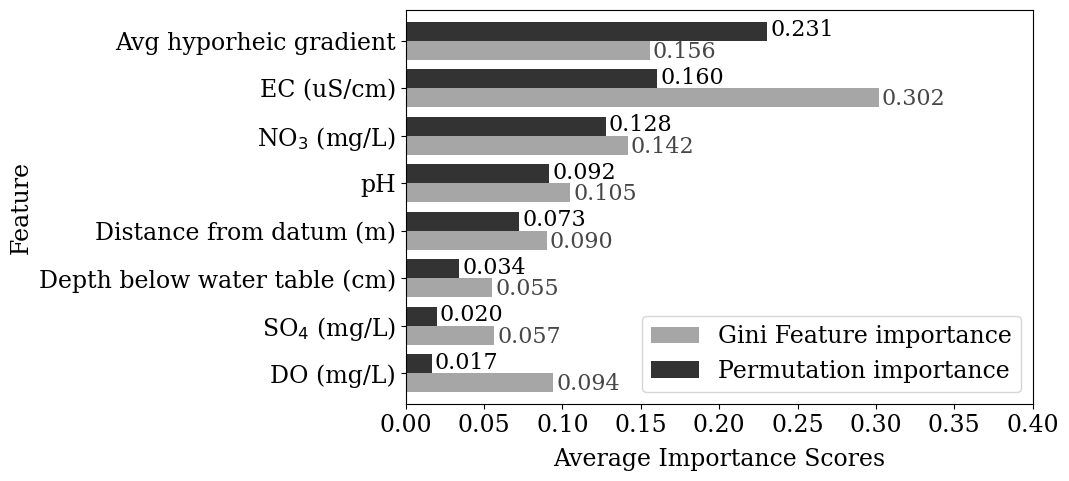

In [49]:
# --- Format feature names for plotting (chemical subscripts) ---
formatted_feature_name = [rename_map.get(f, f) for f in importances_compare.index]

# Create a copy for plotting so original DataFrames stay unchanged
importances_plot = importances_compare.copy()
importances_plot.index = formatted_feature_name

# Set global font, bar colors
plt.rcParams.update({'font.size': 17,'font.family': 'DejaVu Serif'})  
color_fi = "0.65"  
color_pi = "0.2"
num_features = len(importances_compare)
fig_height = max(5, num_features * 0.64)  #height of each bar 

# --- Plot ---
ax = importances_plot.plot(kind="barh", figsize=(11, fig_height), color=[color_fi, color_pi],width =0.8)
# --- Add numerical values next to the bars ---
for i, (fi, pi) in enumerate(zip(importances_compare.iloc[:,0], importances_compare.iloc[:,1])):
#for i, pi in enumerate(importances_compare.iloc[:,1]):
    ax.text(fi + 0.002, i - 0.23, f"{fi:.3f}", va='center', fontsize=16, color="0.28")   # CV FI: cmc.bam(0.01) -> pink
    ax.text(pi + 0.002, i + 0.22, f"{pi:.3f}", va='center', fontsize=16, color="black")   # Perm FI cmc.bam(0.99) --> green

# --- Formatting ---
#ax.legend(["Feature Importance", "Permutation Importance"], fontsize=16)
#ax.legend([ "Permutation Importance"], fontsize=16)
plt.xlim(0,0.4)
plt.xlabel("Average Importance Scores",labelpad=8)
plt.ylabel("Feature")
plt.legend()
#plt.title("RandomForest: CV-averaged Feature importance vs CV-averaged Permutation Importances")
plt.tight_layout()

# 8. Generate Partial dependence plots of 8 main features (Figure 4)
Each fold generates 1 line on the partial dependence plot of each feature. Results from 5 fold were combined. 

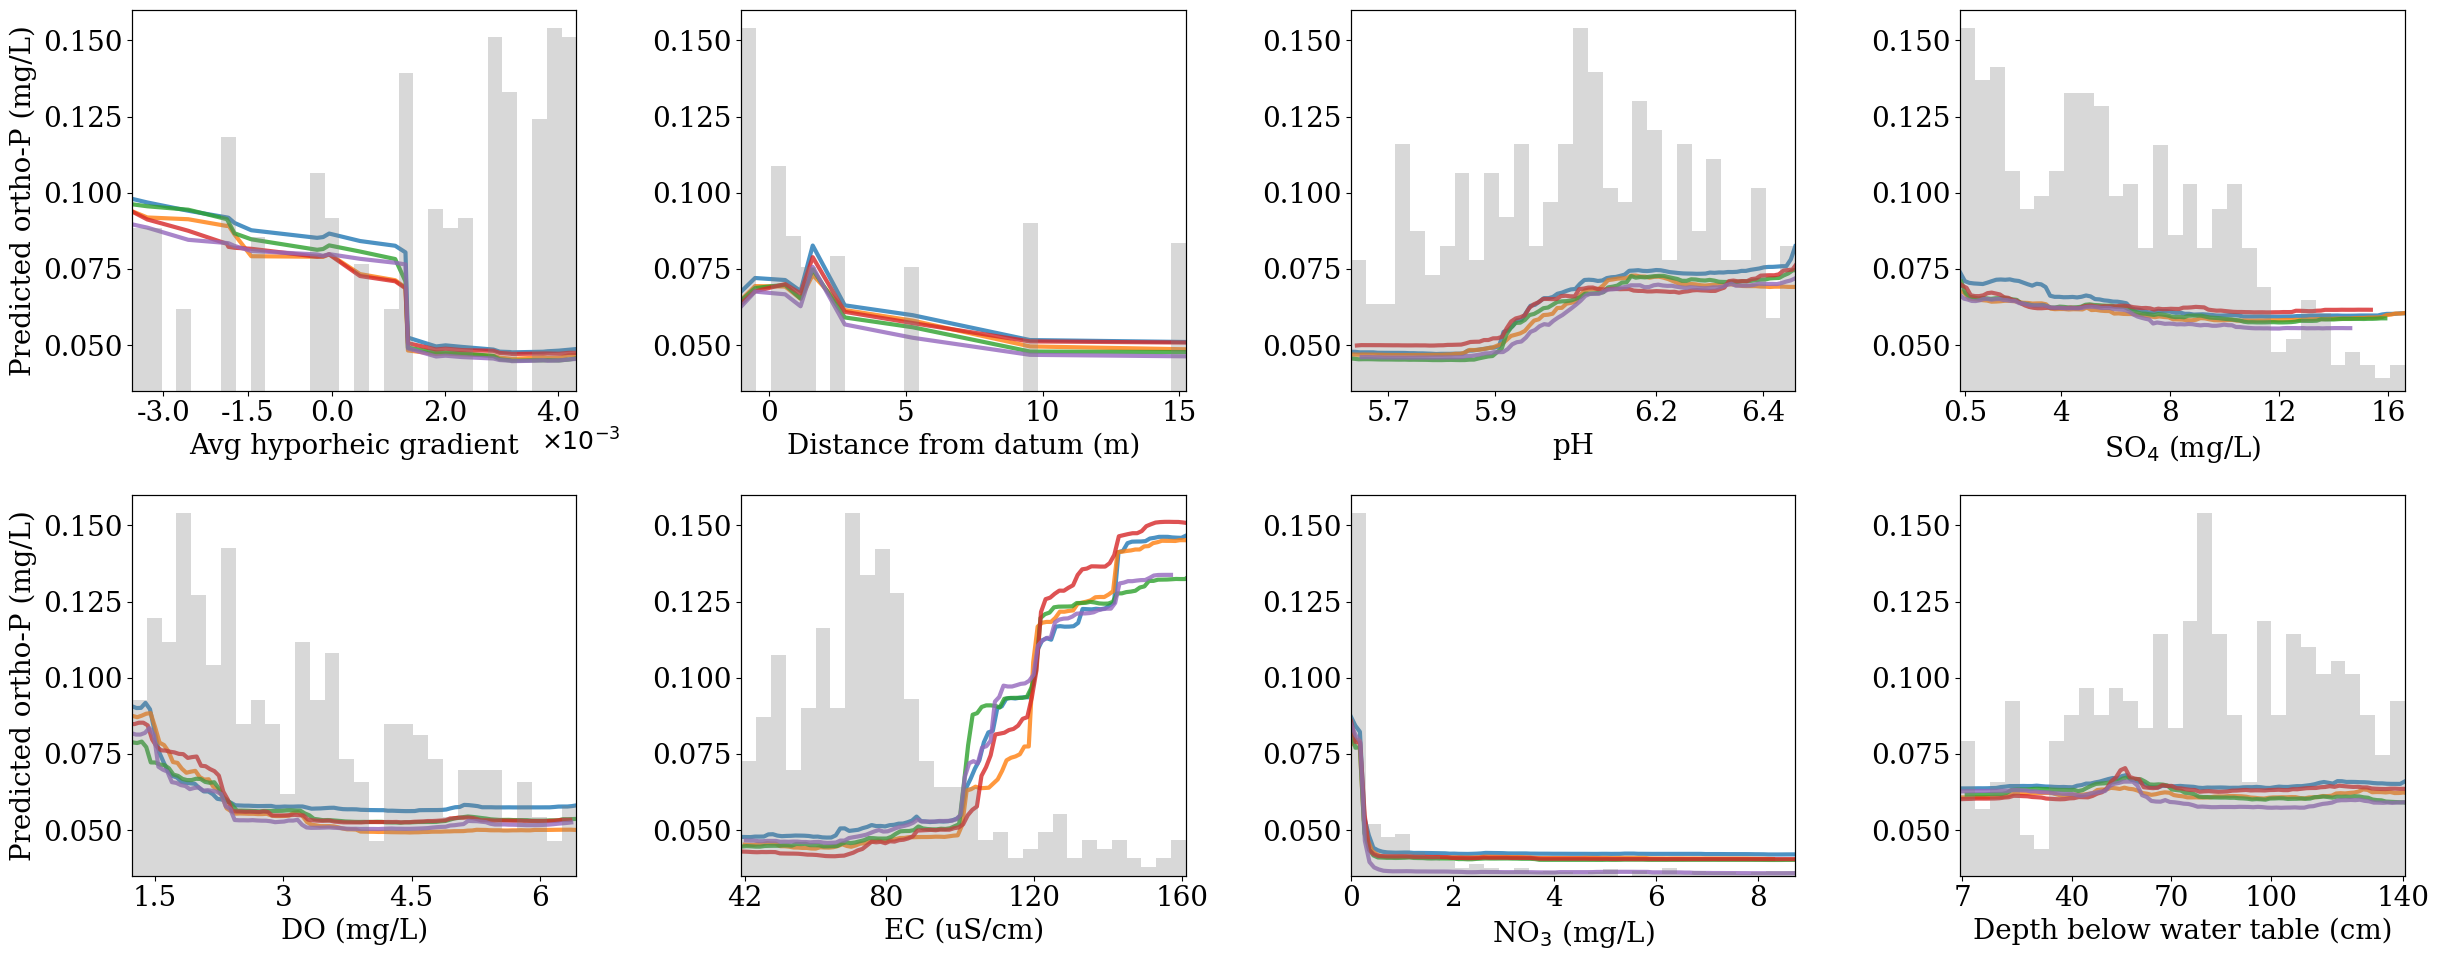

In [50]:

features_to_plot = ['Avg hyporheic gradient','Distance from datum (m)', 'pH', 'SO4 (mg/L)',
                    'DO (mg/L)' ,'EC (uS/cm)','NO3 (mg/L)','Depth below water table (cm)']
plt.rcParams.update({'font.size': 20,'font.family': 'DejaVu Serif'})

n_plot = len(features_to_plot)
n_rows = 2
n_cols = int(np.ceil(n_plot / n_rows))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.2*n_cols, 5*n_rows))
axes = axes.ravel()

# --- Define tick positions manually for each feature ---
tick_dict = {
    'Avg hyporheic gradient': [-0.003, -0.0015, 0, 0.002, 0.004],        # in original units
    'Distance from datum (m)': [0, 5, 10, 15, 20],
    'pH': [5.7, 5.9, 6.2, 6.4],
    'SO4 (mg/L)': [0.5, 4, 8,12, 16],
    'DO (mg/L)': [1.5, 3,4.5,6],
    'EC (uS/cm)': [42, 80,120,160],
    'NO3 (mg/L)': [0, 2, 4, 6,8],
    'Depth below water table (cm)': [7, 40, 70, 100, 140]
}

for i, feat in enumerate(features_to_plot):
    ax_plot = axes[i]

    # Overlay all stored fold curves
    for entry in pdp_all[feat]:
        ax_plot.plot(entry["x"], entry["y"], lw=3, alpha=0.8)

    # Fixed y-axis
    ax_plot.set_ylim(0.035, 0.16)

    # X-limits
    x_vals = pdp_all[feat][0]["x"]
    x_min, x_max = x_vals.min(), x_vals.max()
    ax_plot.set_xlim(x_min, x_max)

    # --- Set tick positions from dictionary
    ticks = tick_dict.get(feat, np.linspace(x_min, x_max, 5))  # fallback
    ax_plot.set_xticks(ticks)

    # Special formatting for Avg hyporheic gradient
    if feat == 'Avg hyporheic gradient':
        ax_plot.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{x*1e3:.1f}"))
        ax_plot.annotate(
            r'$\times 10^{-3}$',
            xy=(0.92, -0.1),
            xycoords='axes fraction', ha='left',  va='top',  fontsize=18  )
    else:
        ax_plot.set_xticklabels([f"{t:g}" for t in ticks])

    # Subscripts for NO3 and SO4
    xlabel = feat.replace('NO3', 'NO$_3$').replace('SO4', 'SO$_4$')
    ax_plot.set_xlabel(xlabel)

    # Y-axis label only for panels in first column
    if i % n_cols == 0:
        ax_plot.set_ylabel("Predicted ortho-P (mg/L)")
    else:
        ax_plot.set_ylabel("")

    # Histogram overlay
    ax_hist = ax_plot.twinx()
    ax_hist.hist(
        X_all[feat], bins=30,density=True, alpha=0.3, color="gray", range=(x_min, x_max))
    ax_hist.set_yticks([])
    ax_hist.set_xlim(x_min, x_max)

plt.tight_layout()
plt.show()